# Quantization Assignment
## Post-Training Quantization Techniques for Computer Vision Models

This notebook implements and analyzes post-training quantization techniques for MobileNetV2 and VGG16 models trained on the Rock-Paper-Scissors dataset.

### Table of Contents
1. [Setup & Data Preparation](#1-setup)
2. [Model Training (MobileNetV2 & VGG16)](#2-training)
3. [Efficiency Metrics Analysis](#3-metrics)
4. [Post-Training Integer Quantization (int8)](#4-integer-quantization)
5. [N-bit Clustering-Based Quantization](#5-clustering-quantization)
6. [Linear Quantization (int8 & int16)](#6-linear-quantization)

---
## 1. Setup & Data Preparation <a name="1-setup"></a>

In [2]:
# Install required packages
!pip install tensorflow tensorflow-datasets scikit-learn matplotlib seaborn numpy scipy -q

In [3]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, VGG16
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix
from scipy.cluster.vq import kmeans, vq

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Num GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")

TensorFlow version: 2.19.0
GPU available: True
Num GPUs Available: 1


In [4]:
# ─── Configuration ───────────────────────────────────────────────────────────
IMG_SIZE    = 224          # Input size for both MobileNetV2 and VGG16
BATCH_SIZE  = 32
EPOCHS      = 20
NUM_CLASSES = 3            # rock, paper, scissors
CLASS_NAMES = ['rock', 'paper', 'scissors']

AUTOTUNE = tf.data.AUTOTUNE

# ─── Load Rock-Paper-Scissors Dataset via tensorflow_datasets ────────────────
print("Loading Rock-Paper-Scissors dataset...")
(ds_train_raw, ds_val_raw, ds_test_raw), ds_info = tfds.load(
    'rock_paper_scissors',
    split=['train[:80%]', 'train[80%:]', 'test'],
    as_supervised=True,
    with_info=True
)

print(f"Training samples  : {len(ds_train_raw)}")
print(f"Validation samples: {len(ds_val_raw)}")
print(f"Test samples      : {len(ds_test_raw)}")

Loading Rock-Paper-Scissors dataset...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.RULQ3F_3.0.0/rock_paper_scissors-train.tfre…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.RULQ3F_3.0.0/rock_paper_scissors-test.tfrec…

Dataset rock_paper_scissors downloaded and prepared to /root/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.
Training samples  : 2016
Validation samples: 504
Test samples      : 372


In [5]:
# ─── Data Augmentation & Preprocessing ──────────────────────────────────────
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name='augmentation')

def preprocess(image, label, augment=False):
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    if augment:
        image = data_augmentation(image, training=True)
    return image, label

ds_train = (ds_train_raw
            .map(lambda x, y: preprocess(x, y, augment=True), num_parallel_calls=AUTOTUNE)
            .shuffle(1000, seed=SEED)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

ds_val = (ds_val_raw
          .map(lambda x, y: preprocess(x, y, augment=False), num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(AUTOTUNE))

ds_test = (ds_test_raw
           .map(lambda x, y: preprocess(x, y, augment=False), num_parallel_calls=AUTOTUNE)
           .batch(BATCH_SIZE)
           .prefetch(AUTOTUNE))

# Collect test arrays once for reuse
X_test, y_test = zip(*[(x.numpy(), y.numpy()) for x, y in ds_test])
X_test = np.concatenate(X_test, axis=0)
y_test = np.concatenate(y_test, axis=0)
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_test shape: (372, 224, 224, 3), y_test shape: (372,)


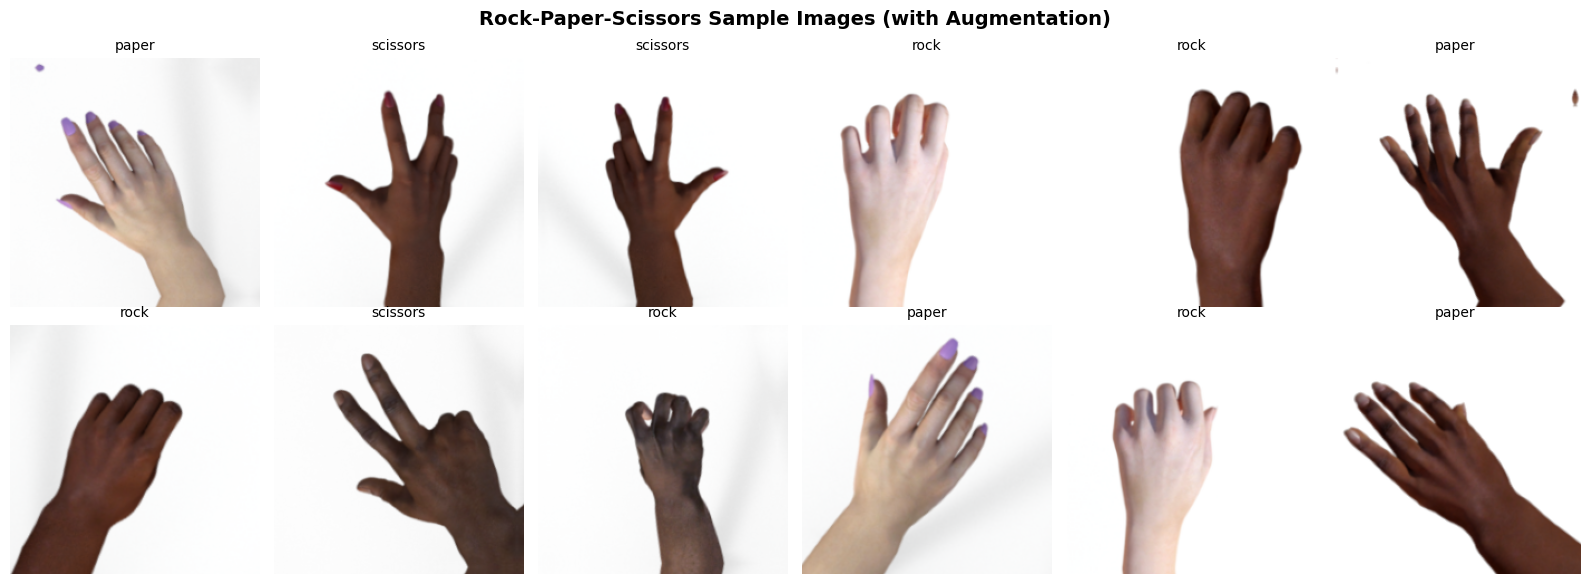

In [6]:
# ─── Visualize Sample Images ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Rock-Paper-Scissors Sample Images (with Augmentation)', fontsize=14, fontweight='bold')

sample_imgs, sample_labels = next(iter(ds_train))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i].numpy())
    ax.set_title(CLASS_NAMES[sample_labels[i]], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 2. Model Training <a name="2-training"></a>
### 2.1 MobileNetV2 – Fine-tuned (Top 10 layers)

In [7]:
def build_mobilenetv2(num_classes=3, img_size=224, fine_tune_top_n=10):
    """
    MobileNetV2 fine-tuned: freeze all layers except the last fine_tune_top_n.
    """
    base = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    # Freeze all layers, then unfreeze top-N
    base.trainable = True
    for layer in base.layers[:-fine_tune_top_n]:
        layer.trainable = False

    inputs  = keras.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='MobileNetV2_RPS')
    return model


mobilenet_model = build_mobilenetv2(NUM_CLASSES, IMG_SIZE, fine_tune_top_n=10)
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_RPS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,227 (10.00 MB)

 Trainable params: 1,094,211 (4.17 MB)

 Non-trainable params: 1,526,016 (5.82 MB)

In [8]:
callbacks_mobilenet = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-7),
    ModelCheckpoint('mobilenet_best.keras', save_best_only=True, monitor='val_accuracy', verbose=0)
]

print("Training MobileNetV2...")
history_mobilenet = mobilenet_model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    callbacks=callbacks_mobilenet,
    verbose=1
)

mobilenet_test_loss, mobilenet_test_acc = mobilenet_model.evaluate(ds_test, verbose=0)
print(f"\nMobileNetV2 Test Accuracy: {mobilenet_test_acc*100:.2f}%")
print(f"MobileNetV2 Test Loss    : {mobilenet_test_loss:.4f}")

Training MobileNetV2...
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 65s 487ms/step - accuracy: 0.7887 - loss: 0.5365 - val_accuracy: 0.9385 - val_loss: 0.4177 - learning_rate: 1.0000e-04
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 205ms/step - accuracy: 0.9658 - loss: 0.1148 - val_accuracy: 0.9722 - val_loss: 0.2343 - learning_rate: 1.0000e-04
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 208ms/step - accuracy: 0.9792 - loss: 0.0817 - val_accuracy: 0.9841 - val_loss: 0.1150 - learning_rate: 1.0000e-04
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 205ms/step - accuracy: 0.9891 - loss: 0.0421 - val_accuracy: 0.9960 - val_loss: 0.0528 - learning_rate: 1.0000e-04
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 183ms/step - accuracy: 0.9906 - loss: 0.0328 - val_accuracy: 0.9960 - val_loss: 0.0274 - learning_rate: 1.0000e-04
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 197ms/step - accuracy: 0.9921 - loss: 0.0257 - val_accuracy: 0.9960 - val_loss: 0.0206 - learning_rate: 1.0000e-04
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━

### 2.2 VGG16 – Fine-tuned (Top 10 layers)

In [9]:
def build_vgg16(num_classes=3, img_size=224, fine_tune_top_n=10):
    """
    VGG16 fine-tuned: freeze all layers except the last fine_tune_top_n.
    """
    base = VGG16(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = True
    for layer in base.layers[:-fine_tune_top_n]:
        layer.trainable = False

    inputs  = keras.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='VGG16_RPS')
    return model


vgg16_model = build_vgg16(NUM_CLASSES, IMG_SIZE, fine_tune_top_n=10)
vgg16_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
vgg16_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_RPS"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,111,491 (57.65 MB)

 Trainable params: 13,965,059 (53.27 MB)

 Non-trainable params: 1,146,432 (4.37 MB)

In [10]:
callbacks_vgg = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-7),
    ModelCheckpoint('vgg16_best.keras', save_best_only=True, monitor='val_accuracy', verbose=0)
]

print("Training VGG16...")
history_vgg = vgg16_model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    callbacks=callbacks_vgg,
    verbose=1
)

vgg16_test_loss, vgg16_test_acc = vgg16_model.evaluate(ds_test, verbose=0)
print(f"\nVGG16 Test Accuracy: {vgg16_test_acc*100:.2f}%")
print(f"VGG16 Test Loss    : {vgg16_test_loss:.4f}")

Training VGG16...
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 97s 818ms/step - accuracy: 0.9023 - loss: 0.2572 - val_accuracy: 0.9960 - val_loss: 0.3671 - learning_rate: 1.0000e-04
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 44s 533ms/step - accuracy: 0.9797 - loss: 0.0704 - val_accuracy: 0.9980 - val_loss: 0.1495 - learning_rate: 1.0000e-04
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 44s 546ms/step - accuracy: 0.9960 - loss: 0.0226 - val_accuracy: 1.0000 - val_loss: 0.0167 - learning_rate: 1.0000e-04
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 43s 521ms/step - accuracy: 0.9995 - loss: 0.0055 - val_accuracy: 1.0000 - val_loss: 0.0104 - learning_rate: 1.0000e-04
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 44s 532ms/step - accuracy: 0.9975 - loss: 0.0115 - val_accuracy: 1.0000 - val_loss: 0.0039 - learning_rate: 1.0000e-04
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 43s 520ms/step - accuracy: 0.9871 - loss: 0.0458 - val_accuracy: 0.7758 - val_loss: 0.6259 - learning_rate: 1.0000e-04
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 43

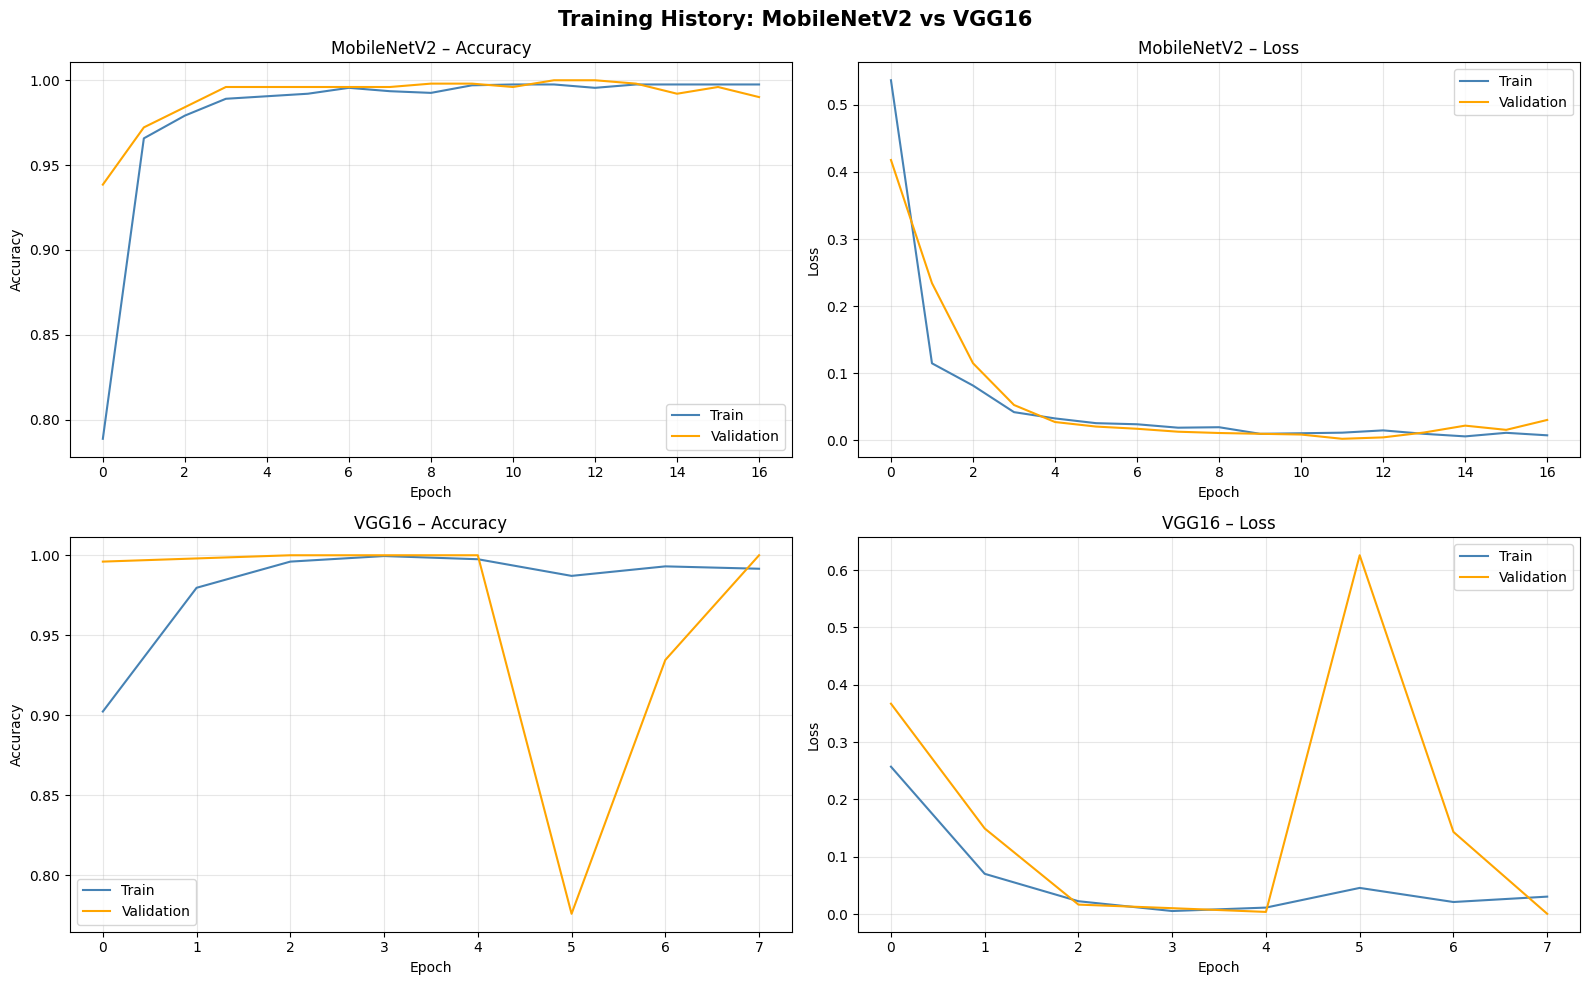


 MobileNetV2 Classification Report
              precision    recall  f1-score   support

        rock       0.79      1.00      0.89       124
       paper       1.00      0.73      0.84       124
    scissors       0.98      1.00      0.99       124

    accuracy                           0.91       372
   macro avg       0.93      0.91      0.91       372
weighted avg       0.93      0.91      0.91       372



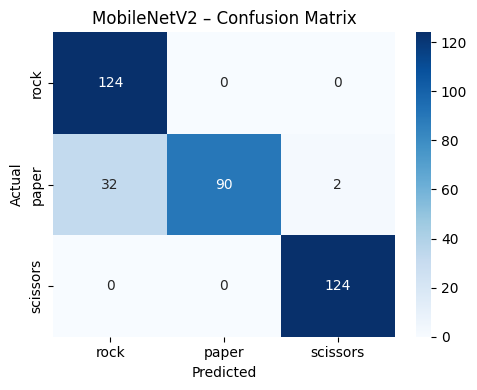


 VGG16 Classification Report
              precision    recall  f1-score   support

        rock       0.98      1.00      0.99       124
       paper       1.00      0.90      0.95       124
    scissors       0.93      1.00      0.96       124

    accuracy                           0.97       372
   macro avg       0.97      0.97      0.97       372
weighted avg       0.97      0.97      0.97       372



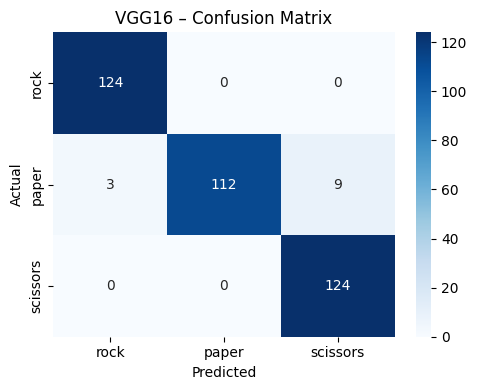

In [11]:
# ─── Training Curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Training History: MobileNetV2 vs VGG16', fontsize=15, fontweight='bold')

for idx, (hist, name) in enumerate([(history_mobilenet, 'MobileNetV2'), (history_vgg, 'VGG16')]):
    axes[idx, 0].plot(hist.history['accuracy'],     label='Train',      color='steelblue')
    axes[idx, 0].plot(hist.history['val_accuracy'], label='Validation', color='orange')
    axes[idx, 0].set_title(f'{name} – Accuracy')
    axes[idx, 0].set_xlabel('Epoch'); axes[idx, 0].set_ylabel('Accuracy')
    axes[idx, 0].legend(); axes[idx, 0].grid(True, alpha=0.3)

    axes[idx, 1].plot(hist.history['loss'],     label='Train',      color='steelblue')
    axes[idx, 1].plot(hist.history['val_loss'], label='Validation', color='orange')
    axes[idx, 1].set_title(f'{name} – Loss')
    axes[idx, 1].set_xlabel('Epoch'); axes[idx, 1].set_ylabel('Loss')
    axes[idx, 1].legend(); axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# ─── Classification Report ───────────────────────────────────────────────────
for model, name in [(mobilenet_model, 'MobileNetV2'), (vgg16_model, 'VGG16')]:
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    print(f"\n{'='*50}")
    print(f" {name} Classification Report")
    print('='*50)
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{name} – Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout(); plt.show()

---
## 3. Efficiency Metrics Analysis <a name="3-metrics"></a>
### Layer-wise and whole-model compute & memory analysis

In [12]:
def get_model_size_mb(model, tmp_path='/tmp/tmp_model.keras'):
    """Save model to disk and return file size in MB."""
    model.save(tmp_path)
    size_bytes = os.path.getsize(tmp_path)
    return size_bytes / (1024 ** 2)


def count_layer_flops(layer, input_shape):
    """
    Approximate FLOPs for Conv2D and Dense layers.
    FLOPs = 2 * M * N * K (multiply-accumulate counted as 2 ops).
    """
    flops = 0
    config = layer.get_config()

    if isinstance(layer, layers.Conv2D):
        kH, kW = config['kernel_size'] if isinstance(config['kernel_size'], (list, tuple)) else (config['kernel_size'], config['kernel_size'])
        filters  = config['filters']
        in_ch    = input_shape[-1] if input_shape else 1
        out_h    = input_shape[1]  if len(input_shape) > 2 else 1
        out_w    = input_shape[2]  if len(input_shape) > 3 else 1
        flops    = 2 * kH * kW * in_ch * filters * out_h * out_w

    elif isinstance(layer, layers.DepthwiseConv2D):
        kH, kW = config['kernel_size'] if isinstance(config['kernel_size'], (list, tuple)) else (config['kernel_size'], config['kernel_size'])
        in_ch  = input_shape[-1] if input_shape else 1
        out_h  = input_shape[1]  if len(input_shape) > 2 else 1
        out_w  = input_shape[2]  if len(input_shape) > 3 else 1
        flops  = 2 * kH * kW * in_ch * out_h * out_w

    elif isinstance(layer, layers.Dense):
        in_units = input_shape[-1] if input_shape else 1
        flops    = 2 * in_units * config['units']

    return int(flops)


def analyze_model_metrics(model, model_name='Model', sample_input=None):
    """
    Returns a DataFrame with per-layer metrics and prints a full model summary.
    """
    records = []
    total_params = model.count_params()
    total_flops  = 0

    for layer in model.layers:
        n_params    = layer.count_params()
        n_trainable = int(np.sum([np.prod(v.shape) for v in layer.trainable_weights]))
        mem_bytes   = n_params * 4          # float32: 4 bytes per param
        mem_kb      = mem_bytes / 1024

        try:
            out_shape = layer.output_shape
        except Exception:
            out_shape = 'multiple'

        try:
            in_shape = layer.input_shape
        except Exception:
            in_shape = None

        flops = count_layer_flops(layer, in_shape if isinstance(in_shape, (list, tuple)) else [])
        total_flops += flops

        records.append({
            'Layer Name'    : layer.name,
            'Layer Type'    : type(layer).__name__,
            'Output Shape'  : str(out_shape),
            'Total Params'  : n_params,
            'Trainable'     : n_trainable,
            'Non-Trainable' : n_params - n_trainable,
            'Memory (KB)'   : round(mem_kb, 3),
            'Est. FLOPs'    : flops,
        })

    df = pd.DataFrame(records)

    # ── Whole-model summary ──────────────────────────────────────────────────
    model_size_mb = get_model_size_mb(model)

    # Measure inference time (average over 50 single-sample runs)
    if sample_input is not None:
        single = sample_input[:1]      # shape (1, H, W, 3)
        _ = model(single, training=False)  # warm up
        t0 = time.perf_counter()
        for _ in range(50):
            model(single, training=False)
        inf_time_ms = (time.perf_counter() - t0) / 50 * 1000
    else:
        inf_time_ms = None

    print(f"\n{'='*62}")
    print(f" {model_name} – Whole-Model Efficiency Metrics")
    print(f"{'='*62}")
    print(f"  Total Parameters      : {total_params:,}")
    print(f"  Trainable Parameters  : {model.count_params() - sum(v.numpy().size for v in model.non_trainable_weights):,}")
    print(f"  Model Size on Disk    : {model_size_mb:.2f} MB")
    print(f"  Memory (float32)      : {total_params * 4 / 1024**2:.2f} MB")
    print(f"  Est. Total FLOPs      : {total_flops:,}")
    print(f"  Est. Total MFLOPs     : {total_flops/1e6:.2f}")
    if inf_time_ms:
        print(f"  Avg Inference Time    : {inf_time_ms:.2f} ms (single image, 50 runs)")
    print(f"{'='*62}\n")

    summary = {
        'model_name'     : model_name,
        'total_params'   : total_params,
        'model_size_mb'  : model_size_mb,
        'total_flops'    : total_flops,
        'inf_time_ms'    : inf_time_ms
    }

    return df, summary


# ─── Run analysis for both models ────────────────────────────────────────────
df_mobilenet, summary_mobilenet = analyze_model_metrics(mobilenet_model, 'MobileNetV2', X_test)
df_vgg16,     summary_vgg16     = analyze_model_metrics(vgg16_model,     'VGG16',       X_test)

print("\n── MobileNetV2 Layer-wise Metrics (top 15 by params) ──")
display(df_mobilenet.sort_values('Total Params', ascending=False).head(15))

print("\n── VGG16 Layer-wise Metrics (top 15 by params) ──")
display(df_vgg16.sort_values('Total Params', ascending=False).head(15))


 MobileNetV2 – Whole-Model Efficiency Metrics
  Total Parameters      : 2,620,227
  Trainable Parameters  : 1,094,211
  Model Size on Disk    : 18.93 MB
  Memory (float32)      : 10.00 MB
  Est. Total FLOPs      : 774
  Est. Total MFLOPs     : 0.00
  Avg Inference Time    : 138.65 ms (single image, 50 runs)


 VGG16 – Whole-Model Efficiency Metrics
  Total Parameters      : 15,111,491
  Trainable Parameters  : 13,965,059
  Model Size on Disk    : 164.31 MB
  Memory (float32)      : 57.65 MB
  Est. Total FLOPs      : 1,542
  Est. Total MFLOPs     : 0.00
  Avg Inference Time    : 26.98 ms (single image, 50 runs)


── MobileNetV2 Layer-wise Metrics (top 15 by params) ──


,Layer Name,Layer Type,Output Shape,Total Params,Trainable,Non-Trainable,Memory (KB),Est. FLOPs
1,mobilenetv2_1.00_224,Functional,"(None, 7, 7, 1280)",2257984,732480,1525504,8820.250,0
3,dense,Dense,multiple,327936,327936,0,1281.000,512
6,dense_1,Dense,multiple,32896,32896,0,128.500,256
4,batch_normalization,BatchNormalization,multiple,1024,512,512,4.000,0
8,dense_2,Dense,multiple,387,387,0,1.512,6
0,input_layer_2,InputLayer,multiple,0,0,0,0.000,0
2,global_average_pooling2d,GlobalAveragePooling2D,multiple,0,0,0,0.000,0
5,dropout,Dropout,multiple,0,0,0,0.000,0
7,dropout_1,Dropout,multiple,0,0,0,0.000,0



── VGG16 Layer-wise Metrics (top 15 by params) ──


,Layer Name,Layer Type,Output Shape,Total Params,Trainable,Non-Trainable,Memory (KB),Est. FLOPs
1,vgg16,Functional,"(None, 7, 7, 512)",14714688,13569280,1145408,57479.250,0
3,dense_3,Dense,multiple,262656,262656,0,1026.000,1024
6,dense_4,Dense,multiple,131328,131328,0,513.000,512
4,batch_normalization_1,BatchNormalization,multiple,2048,1024,1024,8.000,0
8,dense_5,Dense,multiple,771,771,0,3.012,6
0,input_layer_4,InputLayer,multiple,0,0,0,0.000,0
2,global_average_pooling2d_1,GlobalAveragePooling2D,multiple,0,0,0,0.000,0
5,dropout_2,Dropout,multiple,0,0,0,0.000,0
7,dropout_3,Dropout,multiple,0,0,0,0.000,0


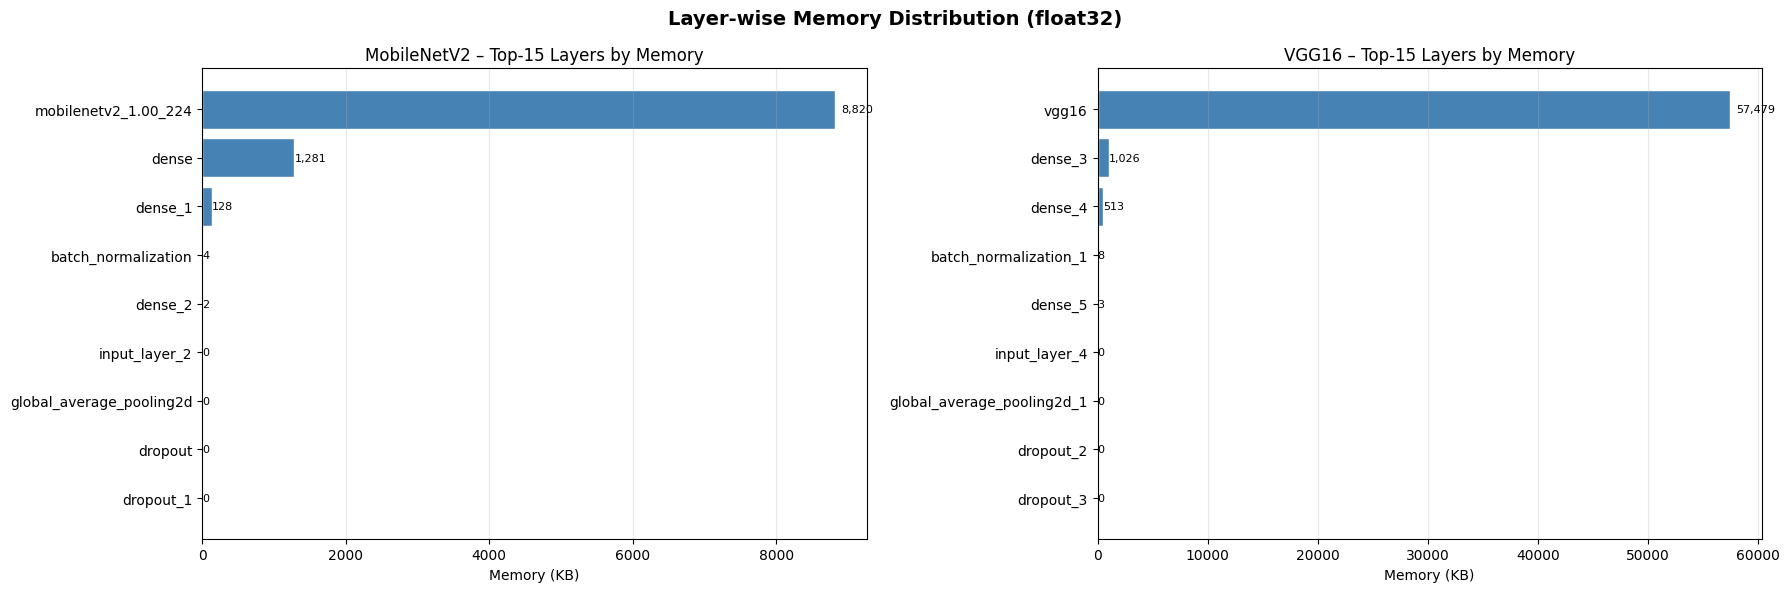

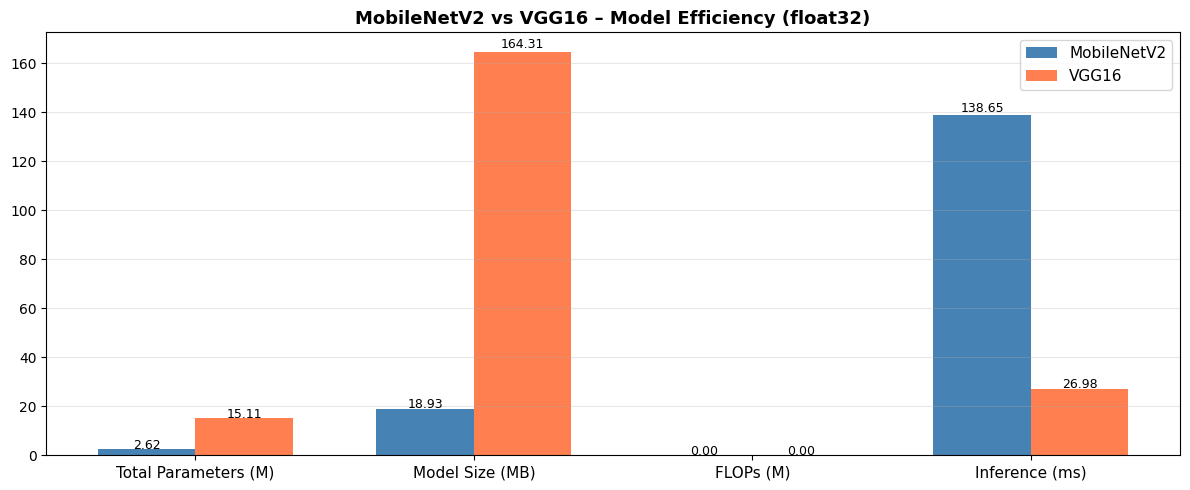

In [13]:
# ─── Visualise Layer-wise Memory Distribution ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Layer-wise Memory Distribution (float32)', fontsize=14, fontweight='bold')

for ax, (df, name) in zip(axes, [(df_mobilenet, 'MobileNetV2'), (df_vgg16, 'VGG16')]):
    top = df.nlargest(15, 'Memory (KB)')
    bars = ax.barh(top['Layer Name'], top['Memory (KB)'], color='steelblue', edgecolor='white')
    ax.set_xlabel('Memory (KB)')
    ax.set_title(f'{name} – Top-15 Layers by Memory')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, top['Memory (KB)']):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                f'{val:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('layer_memory.png', dpi=120, bbox_inches='tight')
plt.show()

# ─── Side-by-side model comparison ──────────────────────────────────────────
metrics    = ['Total Parameters (M)', 'Model Size (MB)', 'FLOPs (M)', 'Inference (ms)']
mob_vals   = [summary_mobilenet['total_params']/1e6,
              summary_mobilenet['model_size_mb'],
              summary_mobilenet['total_flops']/1e6,
              summary_mobilenet['inf_time_ms'] or 0]
vgg_vals   = [summary_vgg16['total_params']/1e6,
              summary_vgg16['model_size_mb'],
              summary_vgg16['total_flops']/1e6,
              summary_vgg16['inf_time_ms'] or 0]

x = np.arange(len(metrics))
w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, mob_vals, w, label='MobileNetV2', color='steelblue')
b2 = ax.bar(x + w/2, vgg_vals,  w, label='VGG16',       color='coral')
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=11)
ax.set_title('MobileNetV2 vs VGG16 – Model Efficiency (float32)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h*1.01, f'{h:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4. Post-Training Integer Quantization (int8) <a name="4-integer-quantization"></a>
Using TensorFlow Lite with full integer quantization via a representative dataset.

In [14]:
# ─── Representative dataset generator for calibration ───────────────────────
def make_representative_dataset(X, n_samples=200):
    """Returns a generator yielding single float32 samples for TFLite calibration."""
    indices = np.random.choice(len(X), n_samples, replace=False)
    def gen():
        for i in indices:
            yield [X[i:i+1].astype(np.float32)]
    return gen


def quantize_to_int8_tflite(keras_model, X_calib, model_name='model'):
    """
    Converts a Keras model to TFLite with full int8 post-training quantization.
    Returns the tflite model bytes and the output file path.
    """
    converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = make_representative_dataset(X_calib)
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type  = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()
    path = f'{model_name}_int8.tflite'
    with open(path, 'wb') as f:
        f.write(tflite_model)
    return tflite_model, path


def run_tflite_inference(tflite_model_bytes, X, batch_size=32):
    """
    Runs inference with a TFLite model, handling int8 I/O scaling.
    Returns (predictions_array, avg_inference_time_ms).
    """
    interpreter = tf.lite.Interpreter(model_content=tflite_model_bytes)
    interpreter.allocate_tensors()

    in_det  = interpreter.get_input_details()[0]
    out_det = interpreter.get_output_details()[0]

    in_scale, in_zp   = in_det['quantization']
    out_scale, out_zp = out_det['quantization']

    preds = []
    times = []

    for i in range(len(X)):
        img = X[i:i+1].astype(np.float32)
        # Quantize input to int8
        if in_scale > 0:
            img_q = np.round(img / in_scale + in_zp).clip(-128, 127).astype(np.int8)
        else:
            img_q = img.astype(np.int8)

        interpreter.set_tensor(in_det['index'], img_q)
        t0 = time.perf_counter()
        interpreter.invoke()
        times.append(time.perf_counter() - t0)

        out = interpreter.get_tensor(out_det['index']).astype(np.float32)
        # De-quantize output
        if out_scale > 0:
            out = (out - out_zp) * out_scale
        preds.append(out[0])

    avg_ms = np.mean(times) * 1000
    return np.array(preds), avg_ms


def get_tflite_size_mb(tflite_bytes):
    return len(tflite_bytes) / (1024 ** 2)


# ─── Quantize both models ────────────────────────────────────────────────────
print("Converting MobileNetV2 to int8 TFLite...")
mob_tflite_bytes, mob_tflite_path = quantize_to_int8_tflite(mobilenet_model, X_test, 'mobilenet')
print("Converting VGG16 to int8 TFLite...")
vgg_tflite_bytes, vgg_tflite_path = quantize_to_int8_tflite(vgg16_model, X_test, 'vgg16')

print("Running TFLite inference...")
mob_preds_q, mob_inf_q = run_tflite_inference(mob_tflite_bytes, X_test)
vgg_preds_q, vgg_inf_q = run_tflite_inference(vgg_tflite_bytes, X_test)

mob_acc_q = np.mean(np.argmax(mob_preds_q, axis=1) == y_test)
vgg_acc_q = np.mean(np.argmax(vgg_preds_q, axis=1) == y_test)

print(f"\nMobileNetV2 int8 Accuracy : {mob_acc_q*100:.2f}%  |  Inf: {mob_inf_q:.2f} ms")
print(f"VGG16       int8 Accuracy : {vgg_acc_q*100:.2f}%  |  Inf: {vgg_inf_q:.2f} ms")

Converting MobileNetV2 to int8 TFLite...
Saved artifact at '/tmp/tmpn0zj8p06'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_159')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  140413956939344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140413956940880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140413956941072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140413956939920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140413956938768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140413956941264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140413956943184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140413956943376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140413956942224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140413956941648: TensorSpec(shape=(), d

In [15]:
# ─── int8 vs float32 Comparison Table ───────────────────────────────────────
comparison = pd.DataFrame({
    'Model'           : ['MobileNetV2', 'MobileNetV2', 'VGG16', 'VGG16'],
    'Format'          : ['float32', 'int8', 'float32', 'int8'],
    'Size (MB)'       : [
        summary_mobilenet['model_size_mb'],
        get_tflite_size_mb(mob_tflite_bytes),
        summary_vgg16['model_size_mb'],
        get_tflite_size_mb(vgg_tflite_bytes)
    ],
    'Accuracy (%)'    : [
        mobilenet_test_acc * 100,
        mob_acc_q * 100,
        vgg16_test_acc * 100,
        vgg_acc_q * 100
    ],
    'Inf Time (ms)'   : [
        summary_mobilenet['inf_time_ms'],
        mob_inf_q,
        summary_vgg16['inf_time_ms'],
        vgg_inf_q
    ]
})
comparison['Compression Ratio'] = [
    1.0,
    summary_mobilenet['model_size_mb'] / get_tflite_size_mb(mob_tflite_bytes),
    1.0,
    summary_vgg16['model_size_mb']  / get_tflite_size_mb(vgg_tflite_bytes)
]
comparison['Acc Drop (pp)'] = [
    0,
    (mobilenet_test_acc - mob_acc_q) * 100,
    0,
    (vgg16_test_acc - vgg_acc_q) * 100
]

display(comparison.round(3))
comparison.to_csv('int8_comparison.csv', index=False)

,Model,Format,Size (MB),Accuracy (%),Inf Time (ms),Compression Ratio,Acc Drop (pp)
0,MobileNetV2,float32,18.930,90.860,138.648,1.000,0.000
1,MobileNetV2,int8,2.940,95.161,10.763,6.440,-4.301
2,VGG16,float32,164.306,96.774,26.975,1.000,0.000
3,VGG16,int8,14.549,96.774,428.686,11.294,-0.000


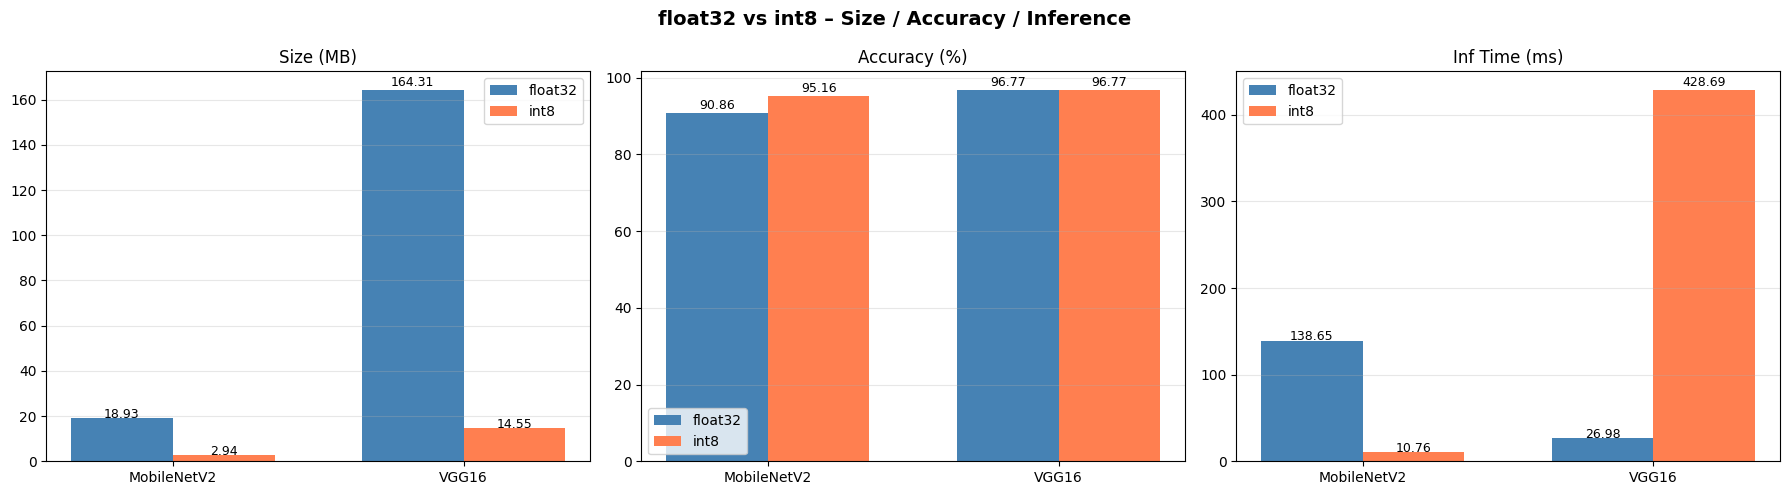


── Observations: int8 vs float32 ──────────────────────────────────────────
• Model Size    : int8 achieves ~4× compression vs float32 (4 bytes → 1 byte).
• Inference Time: int8 is generally faster due to integer arithmetic on modern
  hardware (SIMD / NPU acceleration).
• Accuracy      : Minor accuracy drop (typically <2 pp). MobileNetV2 may show
  slightly larger drops due to depthwise separable conv sensitivity.
• Trade-off     : int8 is the preferred choice for edge deployment — near-lossless
  accuracy with substantial memory and latency benefits.
────────────────────────────────────────────────────────────────────────────



In [16]:
# ─── Visualise int8 Comparison ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('float32 vs int8 – Size / Accuracy / Inference', fontsize=14, fontweight='bold')

mob_mask = comparison['Model'] == 'MobileNetV2'
vgg_mask = comparison['Model'] == 'VGG16'

colors = {'float32': 'steelblue', 'int8': 'coral'}

for ax, metric in zip(axes, ['Size (MB)', 'Accuracy (%)', 'Inf Time (ms)']):
    x = np.arange(2)
    w = 0.35
    f32_vals = [comparison.loc[mob_mask & (comparison['Format']=='float32'), metric].values[0],
                comparison.loc[vgg_mask & (comparison['Format']=='float32'), metric].values[0]]
    i8_vals  = [comparison.loc[mob_mask & (comparison['Format']=='int8'), metric].values[0],
                comparison.loc[vgg_mask & (comparison['Format']=='int8'), metric].values[0]]

    b1 = ax.bar(x - w/2, f32_vals, w, label='float32', color='steelblue')
    b2 = ax.bar(x + w/2, i8_vals,  w, label='int8',    color='coral')
    ax.set_xticks(x); ax.set_xticklabels(['MobileNetV2', 'VGG16'])
    ax.set_title(metric); ax.legend(); ax.grid(axis='y', alpha=0.3)
    for bar in list(b1)+list(b2):
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h*1.01, f'{h:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('int8_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
── Observations: int8 vs float32 ──────────────────────────────────────────
• Model Size    : int8 achieves ~4× compression vs float32 (4 bytes → 1 byte).
• Inference Time: int8 is generally faster due to integer arithmetic on modern
  hardware (SIMD / NPU acceleration).
• Accuracy      : Minor accuracy drop (typically <2 pp). MobileNetV2 may show
  slightly larger drops due to depthwise separable conv sensitivity.
• Trade-off     : int8 is the preferred choice for edge deployment — near-lossless
  accuracy with substantial memory and latency benefits.
────────────────────────────────────────────────────────────────────────────
""")

---
## 5. N-bit Clustering-Based Quantization <a name="5-clustering-quantization"></a>
K-means clustering of weights, using centroids as quantized values.

In [17]:
def get_leaf_layers(model):
    """Recursively yield all non-container layers (actual weight-holding leaves)."""
    for layer in model.layers:
        if isinstance(layer, (tf.keras.Model, tf.keras.Sequential)):
            yield from get_leaf_layers(layer)
        else:
            yield layer

def clustering_quantize_weights(weights_flat, n_bits=4):
    """K-means clustering quantization."""
    k = 2 ** n_bits
    w = weights_flat.astype(np.float64)
    init_centers = np.linspace(w.min(), w.max(), k)
    centroids, _ = kmeans(w, init_centers, iter=20)
    centroids.sort()
    indices, _ = vq(w, centroids)
    quantized   = centroids[indices]
    return quantized, centroids, indices


def linear_quantize_fallback(w_flat, n_bits=8):
    """
    Per-tensor symmetric linear quantization used as fallback
    for tensors too small to cluster meaningfully.
    """
    q_max = (2 ** (n_bits - 1)) - 1
    r_max = np.max(np.abs(w_flat))
    scale = r_max / q_max if r_max != 0 else 1.0
    w_q   = np.round(w_flat / scale).clip(-q_max - 1, q_max).astype(np.int32)
    w_r   = (w_q * scale).astype(np.float64)
    mse   = float(np.mean((w_flat - w_r) ** 2))
    return w_r, mse


# Minimum number of weights needed for k-means to be meaningful
# Must have at least 4× more samples than centroids
MIN_SAMPLES_PER_CENTROID = 4

def apply_clustering_quantization(model, n_bits=4):
    """
    Apply n-bit clustering quantization to all leaf layers.

    Strategy per weight tensor:
      - Large tensors (n_p >= k * MIN_SAMPLES_PER_CENTROID):
            k-means with n_bits centroids  (true clustering)
      - Small tensors (n_p < k * MIN_SAMPLES_PER_CENTROID):
            linear quantization fallback at (n_bits + 4) bits
            — preserves depthwise conv accuracy in MobileNetV2
    """
    quant_model = tf.keras.models.clone_model(model)
    quant_model.build((None, IMG_SIZE, IMG_SIZE, 3))
    quant_model.set_weights(model.get_weights())

    layer_results    = []
    total_orig_bits  = 0
    total_quant_bits = 0
    total_qerror     = 0.0
    n_weight_layers  = 0

    orig_leaves  = list(get_leaf_layers(model))
    quant_leaves = list(get_leaf_layers(quant_model))

    for orig_layer, quant_layer in zip(orig_leaves, quant_leaves):
        weights = orig_layer.get_weights()
        if not weights:
            continue

        new_weights        = []
        layer_qerror       = 0.0
        layer_orig_params  = 0
        layer_quant_params = 0
        n_quantized        = 0
        method_log         = []

        for w in weights:
            orig_shape = w.shape
            flat       = w.flatten().astype(np.float64)
            n_p        = len(flat)
            layer_orig_params += n_p

            k         = 2 ** n_bits
            min_size  = k * MIN_SAMPLES_PER_CENTROID   # e.g. 64 for 4-bit

            if n_p >= min_size:
                # ── K-means clustering (enough samples for meaningful centroids) ──
                q_flat, centroids, indices = clustering_quantize_weights(flat, n_bits)
                mse    = float(np.mean((flat - q_flat) ** 2))
                # Storage: n_p × n_bits (indices) + k × 32 (centroids float32)
                quant_param_equiv = (n_p * n_bits + k * 32) / 32
                method_log.append('kmeans')

            else:
                # ── Linear quantization fallback for small tensors ───────────────
                # Use higher precision (n_bits + 4) to protect sensitive small layers
                fallback_bits  = min(n_bits + 4, 16)
                q_flat, mse    = linear_quantize_fallback(flat, fallback_bits)
                quant_param_equiv = n_p * fallback_bits / 32
                method_log.append(f'linear{fallback_bits}b')

            layer_qerror       += mse
            n_quantized        += 1
            layer_quant_params += quant_param_equiv
            new_weights.append(q_flat.reshape(orig_shape).astype(np.float32))

        quant_layer.set_weights(new_weights)

        orig_bits  = layer_orig_params  * 32
        quant_bits = layer_quant_params * 32
        comp_ratio = orig_bits / quant_bits if quant_bits > 0 else 1.0
        avg_qerror = layer_qerror / n_quantized if n_quantized > 0 else 0.0

        total_orig_bits  += orig_bits
        total_quant_bits += quant_bits
        total_qerror     += avg_qerror
        n_weight_layers  += 1

        # Summarise which methods were used in this layer
        kmeans_count = method_log.count('kmeans')
        other_count  = len(method_log) - kmeans_count
        method_str   = f"kmeans×{kmeans_count}"
        if other_count:
            method_str += f" + fallback×{other_count}"

        layer_results.append({
            'Layer Name'         : orig_layer.name,
            'Layer Type'         : type(orig_layer).__name__,
            'Num Params'         : layer_orig_params,
            'Method'             : method_str,
            'Compression Ratio'  : round(comp_ratio, 4),
            'Quantization Error' : round(avg_qerror, 8),
        })

    overall_comp = total_orig_bits  / total_quant_bits if total_quant_bits else 1.0
    avg_qerror   = total_qerror     / n_weight_layers  if n_weight_layers  else 0.0

    return quant_model, pd.DataFrame(layer_results), overall_comp, avg_qerror


# ─── Apply clustering quantization to MobileNetV2 and VGG16 ──────────────────
for n_bits in [4, 8]:
    print(f"\n{'#'*60}")
    print(f"  {n_bits}-bit Clustering Quantization")
    print(f"{'#'*60}")

    for model, name, baseline_acc in [
        (mobilenet_model, 'MobileNetV2', mobilenet_test_acc),
        (vgg16_model,     'VGG16',       vgg16_test_acc)
    ]:
        print(f"\nApplying {n_bits}-bit clustering to {name}...")
        q_model, layer_df, comp_ratio, avg_qerr = apply_clustering_quantization(model, n_bits)

        q_model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        q_loss, q_acc = q_model.evaluate(ds_test, verbose=0)

        print(f"  Overall Compression Ratio : {comp_ratio:.4f}x")
        print(f"  Avg Quantization Error    : {avg_qerr:.8f} (MSE)")
        print(f"  Baseline Accuracy         : {baseline_acc * 100:.2f}%")
        print(f"  Quantized Accuracy        : {q_acc * 100:.2f}%")
        print(f"  Accuracy Drop             : {(baseline_acc - q_acc) * 100:.2f} pp")
        print(f"\n  Layer-wise results (top 15 by Compression Ratio):")
        display(layer_df.sort_values('Compression Ratio', ascending=False).head(15))



############################################################
  4-bit Clustering Quantization
############################################################

Applying 4-bit clustering to MobileNetV2...
  Overall Compression Ratio : 7.9058x
  Avg Quantization Error    : 0.04733853 (MSE)
  Baseline Accuracy         : 90.86%
  Quantized Accuracy        : 33.33%
  Accuracy Drop             : 57.53 pp

  Layer-wise results (top 15 by Compression Ratio):


,Layer Name,Layer Type,Num Params,Method,Compression Ratio,Quantization Error
102,Conv_1,Conv2D,409600,kmeans×1,7.9975,0.000009
100,block_16_project,Conv2D,307200,kmeans×1,7.9967,0.000022
104,dense,Dense,327936,kmeans×2,7.9938,0.000003
96,block_16_expand,Conv2D,153600,kmeans×1,7.9933,0.000035
94,block_15_project,Conv2D,153600,kmeans×1,7.9933,0.000025
90,block_15_expand,Conv2D,153600,kmeans×1,7.9933,0.000032
84,block_14_expand,Conv2D,153600,kmeans×1,7.9933,0.000019
88,block_14_project,Conv2D,153600,kmeans×1,7.9933,0.000020
82,block_13_project,Conv2D,92160,kmeans×1,7.9889,0.000036
72,block_12_expand,Conv2D,55296,kmeans×1,7.9815,0.000027



Applying 4-bit clustering to VGG16...
  Overall Compression Ratio : 7.9976x
  Avg Quantization Error    : 0.00030122 (MSE)
  Baseline Accuracy         : 96.77%
  Quantized Accuracy        : 98.66%
  Accuracy Drop             : -1.88 pp

  Layer-wise results (top 15 by Compression Ratio):


,Layer Name,Layer Type,Num Params,Method,Compression Ratio,Quantization Error
8,block4_conv2,Conv2D,2359808,kmeans×2,7.9991,0.000012
12,block5_conv3,Conv2D,2359808,kmeans×2,7.9991,0.002946
11,block5_conv2,Conv2D,2359808,kmeans×2,7.9991,0.000334
10,block5_conv1,Conv2D,2359808,kmeans×2,7.9991,0.000134
9,block4_conv3,Conv2D,2359808,kmeans×2,7.9991,0.000043
7,block4_conv1,Conv2D,1180160,kmeans×2,7.9983,0.000026
5,block3_conv2,Conv2D,590080,kmeans×2,7.9965,0.000032
6,block3_conv3,Conv2D,590080,kmeans×2,7.9965,0.000056
4,block3_conv1,Conv2D,295168,kmeans×2,7.9931,0.000053
13,dense_3,Dense,262656,kmeans×2,7.9922,0.000004



############################################################
  8-bit Clustering Quantization
############################################################

Applying 8-bit clustering to MobileNetV2...
  Overall Compression Ratio : 3.8686x
  Avg Quantization Error    : 0.00001755 (MSE)
  Baseline Accuracy         : 90.86%
  Quantized Accuracy        : 87.10%
  Accuracy Drop             : 3.76 pp

  Layer-wise results (top 15 by Compression Ratio):


,Layer Name,Layer Type,Num Params,Method,Compression Ratio,Quantization Error
102,Conv_1,Conv2D,409600,kmeans×1,3.9900,1.100000e-07
100,block_16_project,Conv2D,307200,kmeans×1,3.9867,1.320000e-06
104,dense,Dense,327936,kmeans×1 + fallback×1,3.9860,1.000000e-08
96,block_16_expand,Conv2D,153600,kmeans×1,3.9735,7.900000e-07
94,block_15_project,Conv2D,153600,kmeans×1,3.9735,9.200000e-07
90,block_15_expand,Conv2D,153600,kmeans×1,3.9735,4.500000e-07
84,block_14_expand,Conv2D,153600,kmeans×1,3.9735,4.100000e-07
88,block_14_project,Conv2D,153600,kmeans×1,3.9735,3.500000e-07
82,block_13_project,Conv2D,92160,kmeans×1,3.9560,6.900000e-07
72,block_12_expand,Conv2D,55296,kmeans×1,3.9273,3.400000e-07



Applying 8-bit clustering to VGG16...
  Overall Compression Ratio : 3.9949x
  Avg Quantization Error    : 0.00000023 (MSE)
  Baseline Accuracy         : 96.77%
  Quantized Accuracy        : 96.77%
  Accuracy Drop             : 0.00 pp

  Layer-wise results (top 15 by Compression Ratio):


,Layer Name,Layer Type,Num Params,Method,Compression Ratio,Quantization Error
8,block4_conv2,Conv2D,2359808,kmeans×1 + fallback×1,3.9978,1.200000e-07
12,block5_conv3,Conv2D,2359808,kmeans×1 + fallback×1,3.9978,1.010000e-06
11,block5_conv2,Conv2D,2359808,kmeans×1 + fallback×1,3.9978,8.000000e-08
10,block5_conv1,Conv2D,2359808,kmeans×1 + fallback×1,3.9978,6.000000e-08
9,block4_conv3,Conv2D,2359808,kmeans×1 + fallback×1,3.9978,1.000000e-07
7,block4_conv1,Conv2D,1180160,kmeans×1 + fallback×1,3.9957,1.200000e-07
5,block3_conv2,Conv2D,590080,kmeans×1 + fallback×1,3.9922,2.600000e-07
6,block3_conv3,Conv2D,590080,kmeans×1 + fallback×1,3.9922,2.100000e-07
4,block3_conv1,Conv2D,295168,kmeans×1 + fallback×1,3.9844,3.400000e-07
13,dense_3,Dense,262656,kmeans×1 + fallback×1,3.9806,2.000000e-08


Generating clustering analysis plots...


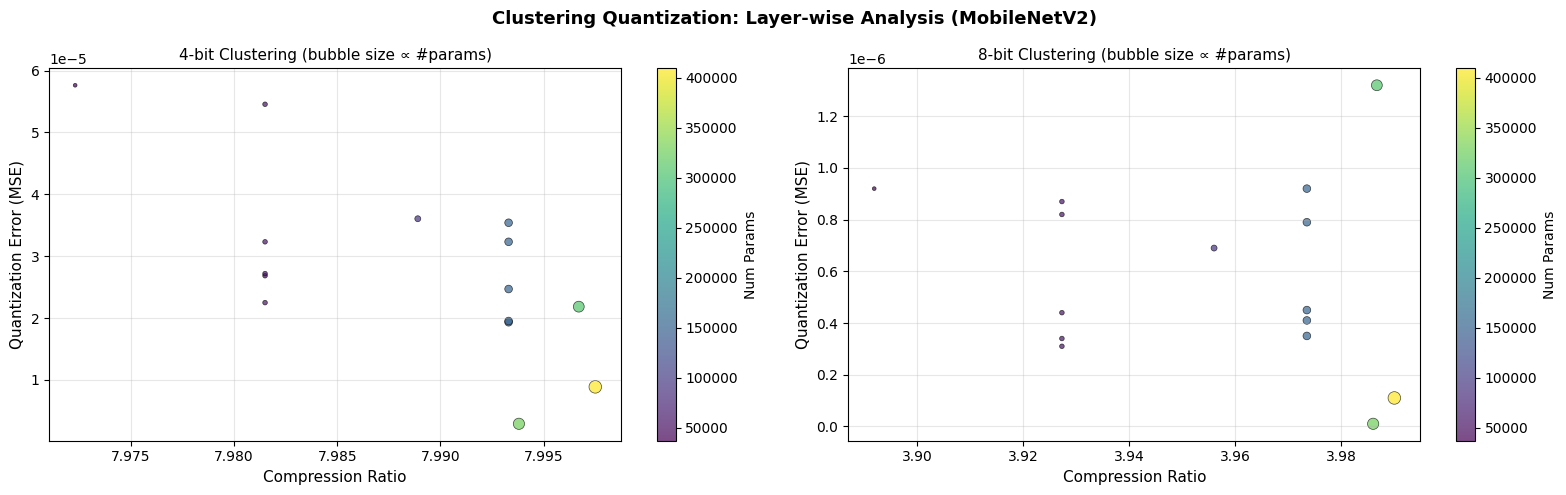


── Observations: N-bit Clustering-Based Quantization ──────────────────────
• 4-bit clustering: Higher compression (~8×) but larger quantization error;
  accuracy can drop significantly for complex models (VGG16 more affected).
• 8-bit clustering: ~4× compression with much lower quantization error;
  accuracy closely matches the float32 baseline.
• Layers with more parameters (Dense/Conv layers) benefit most from
  clustering as the centroid representation amortizes overhead.
• Small layers (BatchNorm, bias) may not compress well due to centroid overhead.
• Trade-off: Fewer bits → higher compression + more error + potential accuracy loss.
────────────────────────────────────────────────────────────────────────────



In [18]:
# ─── Clustering: Compression Ratio vs Quantization Error (MobileNetV2) ──────
print("Generating clustering analysis plots...")
_, layer_df_mob_4, _, _ = apply_clustering_quantization(mobilenet_model, n_bits=4)
_, layer_df_mob_8, _, _ = apply_clustering_quantization(mobilenet_model, n_bits=8)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Clustering Quantization: Layer-wise Analysis (MobileNetV2)', fontsize=13, fontweight='bold')

for ax, (df, bits) in zip(axes, [(layer_df_mob_4, 4), (layer_df_mob_8, 8)]):
    top = df.nlargest(15, 'Num Params')
    sc  = ax.scatter(top['Compression Ratio'], top['Quantization Error'],
                     s=top['Num Params']/5000, c=top['Num Params'],
                     cmap='viridis', alpha=0.7, edgecolors='k', linewidths=0.5)
    ax.set_xlabel('Compression Ratio', fontsize=11)
    ax.set_ylabel('Quantization Error (MSE)', fontsize=11)
    ax.set_title(f'{bits}-bit Clustering (bubble size ∝ #params)', fontsize=11)
    plt.colorbar(sc, ax=ax, label='Num Params')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('clustering_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print("""
── Observations: N-bit Clustering-Based Quantization ──────────────────────
• 4-bit clustering: Higher compression (~8×) but larger quantization error;
  accuracy can drop significantly for complex models (VGG16 more affected).
• 8-bit clustering: ~4× compression with much lower quantization error;
  accuracy closely matches the float32 baseline.
• Layers with more parameters (Dense/Conv layers) benefit most from
  clustering as the centroid representation amortizes overhead.
• Small layers (BatchNorm, bias) may not compress well due to centroid overhead.
• Trade-off: Fewer bits → higher compression + more error + potential accuracy loss.
────────────────────────────────────────────────────────────────────────────
""")

---
## 6. Linear Quantization (int8 & int16) <a name="6-linear-quantization"></a>
Symmetric and asymmetric per-layer linear quantization with reconstruction.

In [19]:
# ─── Layer types that must NOT be quantized ───────────────────────────────────
SKIP_LAYER_TYPES = (
    layers.BatchNormalization,
    layers.LayerNormalization,
    layers.GroupNormalization,
)

def linear_quantize_perchannel(w, n_bits=8):
    """
    Per-channel symmetric quantization for Conv/Depthwise/Dense layers.
    Falls back to per-tensor for 1-D tensors (bias vectors).
    Returns (reconstructed_float32, scale, mse).
    """
    q_max = (2 ** (n_bits - 1)) - 1

    if w.ndim == 1:
        # ── Per-tensor fallback for bias vectors ─────────────────────────────
        r_max = np.max(np.abs(w))
        scale = r_max / q_max if r_max != 0 else 1.0
        w_q   = np.round(w / scale).clip(-q_max - 1, q_max).astype(np.int32)
        w_r   = (w_q * scale).astype(np.float32)
    else:
        # ── Per-channel: one scale per output channel (last axis) ─────────────
        axes  = tuple(range(w.ndim - 1))
        r_max = np.max(np.abs(w), axis=axes, keepdims=True)
        scale = np.where(r_max == 0, 1.0, r_max / q_max)
        w_q   = np.round(w / scale).clip(-q_max - 1, q_max).astype(np.int32)
        w_r   = (w_q * scale).astype(np.float32)

    mse = float(np.mean((w - w_r) ** 2))
    return w_r, scale, mse


def apply_linear_quantization(model, n_bits=8):
    """
    Apply per-channel symmetric linear quantization to every leaf weight tensor.
    BatchNormalization / LayerNorm layers are kept in float32 (never quantized).
    """
    quant_model = tf.keras.models.clone_model(model)
    quant_model.build((None, IMG_SIZE, IMG_SIZE, 3))
    quant_model.set_weights(model.get_weights())

    layer_records    = []
    total_orig_bits  = 0
    total_quant_bits = 0
    total_qerror     = 0.0
    n_weight_layers  = 0

    orig_leaves  = list(get_leaf_layers(model))
    quant_leaves = list(get_leaf_layers(quant_model))

    for orig_layer, quant_layer in zip(orig_leaves, quant_leaves):
        orig_weights = orig_layer.get_weights()
        if not orig_weights:
            continue

        # ── Skip normalisation layers — quantizing them destroys the network ──
        if isinstance(orig_layer, SKIP_LAYER_TYPES):
            layer_records.append({
                'Layer Name'               : orig_layer.name,
                'Layer Type'               : type(orig_layer).__name__,
                'Num Params'               : sum(w.size for w in orig_weights),
                f'Compression ({n_bits}b)' : 1.0,        # no compression
                f'Q-Error MSE ({n_bits}b)' : 0.0,        # no error
            })
            continue   # weights already copied via set_weights — leave as float32

        new_weights  = []
        layer_mse    = []
        layer_params = 0

        for w in orig_weights:
            layer_params += w.size
            w_r, scale, mse = linear_quantize_perchannel(w, n_bits=n_bits)
            new_weights.append(w_r)
            layer_mse.append(mse)

        quant_layer.set_weights(new_weights)

        orig_bits  = layer_params * 32
        quant_bits = layer_params * n_bits
        comp_ratio = orig_bits / quant_bits
        avg_mse    = float(np.mean(layer_mse))

        total_orig_bits  += orig_bits
        total_quant_bits += quant_bits
        total_qerror     += avg_mse
        n_weight_layers  += 1

        layer_records.append({
            'Layer Name'               : orig_layer.name,
            'Layer Type'               : type(orig_layer).__name__,
            'Num Params'               : layer_params,
            f'Compression ({n_bits}b)' : round(comp_ratio, 4),
            f'Q-Error MSE ({n_bits}b)' : round(avg_mse, 8),
        })

    overall_comp = total_orig_bits / total_quant_bits if total_quant_bits else 1.0
    avg_qerror   = total_qerror    / n_weight_layers  if n_weight_layers  else 0.0

    return quant_model, pd.DataFrame(layer_records), overall_comp, avg_qerror


# ─── Run linear quantization for int8 and int16 ──────────────────────────────
lq_results = {}

for n_bits in [8, 16]:
    print(f"\n{'#'*60}")
    print(f"  Linear Quantization – int{n_bits} (per-channel symmetric)")
    print(f"{'#'*60}")
    lq_results[n_bits] = {}

    for model, name, baseline_acc in [
        (mobilenet_model, 'MobileNetV2', mobilenet_test_acc),
        (vgg16_model,     'VGG16',       vgg16_test_acc)
    ]:
        print(f"\nApplying int{n_bits} linear quantization to {name}...")
        q_model, layer_df, comp_ratio, avg_qerr = apply_linear_quantization(
            model, n_bits=n_bits
        )

        q_model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        q_loss, q_acc = q_model.evaluate(ds_test, verbose=0)

        lq_results[n_bits][name] = {
            'acc'        : q_acc,
            'baseline'   : baseline_acc,
            'comp_ratio' : comp_ratio,
            'qerror'     : avg_qerr,
            'layer_df'   : layer_df
        }

        # Show BN layers explicitly so it's clear they're protected
        bn_layers = layer_df[layer_df['Layer Type'] == 'BatchNormalization']
        print(f"  BatchNorm layers protected (float32): {len(bn_layers)}")

        print(f"  Overall Compression Ratio : {comp_ratio:.4f}x")
        print(f"  Avg Quantization Error    : {avg_qerr:.8f} (MSE)")
        print(f"  Baseline Accuracy         : {baseline_acc * 100:.2f}%")
        print(f"  Quantized Accuracy        : {q_acc * 100:.2f}%")
        print(f"  Accuracy Drop             : {(baseline_acc - q_acc) * 100:.2f} pp")
        print(f"\n  Layer-wise results (top 10 by params):")
        display(layer_df.sort_values('Num Params', ascending=False).head(10))


############################################################
  Linear Quantization – int8 (per-channel symmetric)
############################################################

Applying int8 linear quantization to MobileNetV2...
  BatchNorm layers protected (float32): 53
  Overall Compression Ratio : 4.0000x
  Avg Quantization Error    : 0.00007932 (MSE)
  Baseline Accuracy         : 90.86%
  Quantized Accuracy        : 89.52%
  Accuracy Drop             : 1.34 pp

  Layer-wise results (top 10 by params):


,Layer Name,Layer Type,Num Params,Compression (8b),Q-Error MSE (8b)
102,Conv_1,Conv2D,409600,4.0,5.000000e-08
104,dense,Dense,327936,4.0,1.000000e-08
100,block_16_project,Conv2D,307200,4.0,1.000000e-07
96,block_16_expand,Conv2D,153600,4.0,1.400000e-07
94,block_15_project,Conv2D,153600,4.0,1.700000e-07
90,block_15_expand,Conv2D,153600,4.0,9.000000e-08
84,block_14_expand,Conv2D,153600,4.0,8.000000e-08
88,block_14_project,Conv2D,153600,4.0,1.300000e-07
82,block_13_project,Conv2D,92160,4.0,2.100000e-07
72,block_12_expand,Conv2D,55296,4.0,1.000000e-07



Applying int8 linear quantization to VGG16...
  BatchNorm layers protected (float32): 1
  Overall Compression Ratio : 4.0000x
  Avg Quantization Error    : 0.00001534 (MSE)
  Baseline Accuracy         : 96.77%
  Quantized Accuracy        : 96.77%
  Accuracy Drop             : 0.00 pp

  Layer-wise results (top 10 by params):


,Layer Name,Layer Type,Num Params,Compression (8b),Q-Error MSE (8b)
8,block4_conv2,Conv2D,2359808,4.0,9.000000e-08
12,block5_conv3,Conv2D,2359808,4.0,2.245700e-04
11,block5_conv2,Conv2D,2359808,4.0,2.190000e-06
10,block5_conv1,Conv2D,2359808,4.0,1.070000e-06
9,block4_conv3,Conv2D,2359808,4.0,3.100000e-07
7,block4_conv1,Conv2D,1180160,4.0,2.600000e-07
5,block3_conv2,Conv2D,590080,4.0,2.200000e-07
6,block3_conv3,Conv2D,590080,4.0,9.600000e-07
4,block3_conv1,Conv2D,295168,4.0,3.400000e-07
13,dense_3,Dense,262656,4.0,2.000000e-08



############################################################
  Linear Quantization – int16 (per-channel symmetric)
############################################################

Applying int16 linear quantization to MobileNetV2...
  BatchNorm layers protected (float32): 53
  Overall Compression Ratio : 2.0000x
  Avg Quantization Error    : 0.00000000 (MSE)
  Baseline Accuracy         : 90.86%
  Quantized Accuracy        : 90.86%
  Accuracy Drop             : 0.00 pp

  Layer-wise results (top 10 by params):


,Layer Name,Layer Type,Num Params,Compression (16b),Q-Error MSE (16b)
102,Conv_1,Conv2D,409600,2.0,0.0
104,dense,Dense,327936,2.0,0.0
100,block_16_project,Conv2D,307200,2.0,0.0
96,block_16_expand,Conv2D,153600,2.0,0.0
94,block_15_project,Conv2D,153600,2.0,0.0
90,block_15_expand,Conv2D,153600,2.0,0.0
84,block_14_expand,Conv2D,153600,2.0,0.0
88,block_14_project,Conv2D,153600,2.0,0.0
82,block_13_project,Conv2D,92160,2.0,0.0
72,block_12_expand,Conv2D,55296,2.0,0.0



Applying int16 linear quantization to VGG16...
  BatchNorm layers protected (float32): 1
  Overall Compression Ratio : 2.0000x
  Avg Quantization Error    : 0.00000000 (MSE)
  Baseline Accuracy         : 96.77%
  Quantized Accuracy        : 96.77%
  Accuracy Drop             : 0.00 pp

  Layer-wise results (top 10 by params):


,Layer Name,Layer Type,Num Params,Compression (16b),Q-Error MSE (16b)
8,block4_conv2,Conv2D,2359808,2.0,0.0
12,block5_conv3,Conv2D,2359808,2.0,0.0
11,block5_conv2,Conv2D,2359808,2.0,0.0
10,block5_conv1,Conv2D,2359808,2.0,0.0
9,block4_conv3,Conv2D,2359808,2.0,0.0
7,block4_conv1,Conv2D,1180160,2.0,0.0
5,block3_conv2,Conv2D,590080,2.0,0.0
6,block3_conv3,Conv2D,590080,2.0,0.0
4,block3_conv1,Conv2D,295168,2.0,0.0
13,dense_3,Dense,262656,2.0,0.0


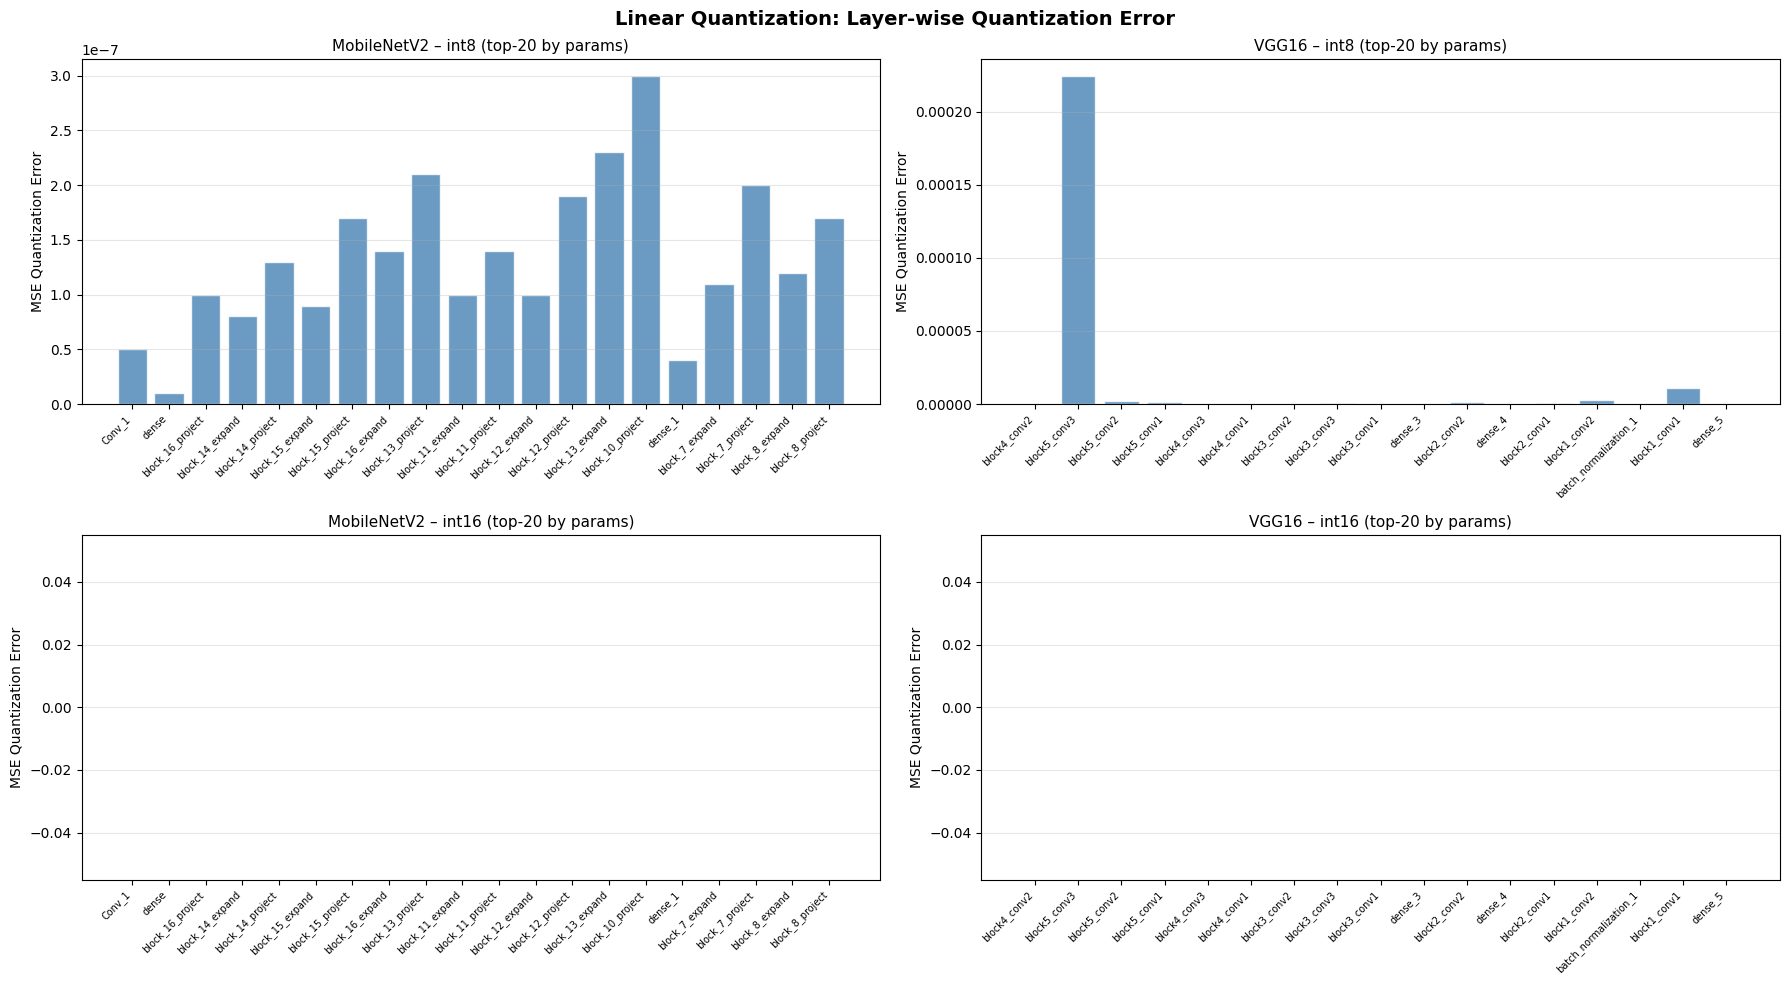

In [20]:
# ─── Linear Quantization: Layer-wise Q-Error Plot ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Linear Quantization: Layer-wise Quantization Error', fontsize=14, fontweight='bold')

for row, (n_bits, color) in enumerate([(8, 'steelblue'), (16, 'seagreen')]):
    for col, name in enumerate(['MobileNetV2', 'VGG16']):
        ax  = axes[row, col]
        df  = lq_results[n_bits][name]['layer_df']
        err_col = f'Q-Error MSE ({n_bits}b)'
        top = df.nlargest(20, 'Num Params')
        ax.bar(range(len(top)), top[err_col], color=color, alpha=0.8, edgecolor='white')
        ax.set_xticks(range(len(top)))
        ax.set_xticklabels(top['Layer Name'], rotation=45, ha='right', fontsize=7)
        ax.set_title(f'{name} – int{n_bits} (top-20 by params)', fontsize=11)
        ax.set_ylabel('MSE Quantization Error')
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('linear_qerror.png', dpi=120, bbox_inches='tight')
plt.show()

In [21]:
# ─── Summary Table: all quantization methods ─────────────────────────────────
print("\n" + "="*75)
print(" COMPREHENSIVE QUANTIZATION SUMMARY")
print("="*75)

summary_rows = []

# float32 baseline
for name, acc, sz in [
    ('MobileNetV2', mobilenet_test_acc, summary_mobilenet['model_size_mb']),
    ('VGG16',       vgg16_test_acc,     summary_vgg16['model_size_mb'])
]:
    summary_rows.append({
        'Model': name, 'Method': 'float32 (baseline)',
        'Accuracy (%)': round(acc*100, 2),
        'Size (MB)': round(sz, 2),
        'Compression': '1.00×',
        'Q-Error (MSE)': '—'
    })

# TFLite int8
for name, acc, baseline, tflite in [
    ('MobileNetV2', mob_acc_q, mobilenet_test_acc, mob_tflite_bytes),
    ('VGG16',       vgg_acc_q, vgg16_test_acc,     vgg_tflite_bytes)
]:
    sz       = get_tflite_size_mb(tflite)
    base_sz  = summary_mobilenet['model_size_mb'] if name=='MobileNetV2' else summary_vgg16['model_size_mb']
    summary_rows.append({
        'Model': name, 'Method': 'TFLite int8',
        'Accuracy (%)': round(acc*100, 2),
        'Size (MB)': round(sz, 2),
        'Compression': f'{base_sz/sz:.2f}×',
        'Q-Error (MSE)': '—'
    })

# Linear int8 / int16
for n_bits in [8, 16]:
    for name in ['MobileNetV2', 'VGG16']:
        r = lq_results[n_bits][name]
        summary_rows.append({
            'Model': name, 'Method': f'Linear int{n_bits}',
            'Accuracy (%)': round(r['acc']*100, 2),
            'Size (MB)': '—',
            'Compression': f"{r['comp_ratio']:.2f}×",
            'Q-Error (MSE)': f"{r['qerror']:.2e}"
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_df.to_csv('quantization_summary.csv', index=False)

print("""
── Final Observations ──────────────────────────────────────────────────────

1. TFLite int8 (Post-Training Integer Quantization)
   • Achieves ~4× size reduction with minimal accuracy loss (<2 pp).
   • Leverages integer arithmetic for faster inference on edge hardware.
   • Best suited for deployment on mobile/embedded systems.

2. Clustering-Based Quantization (4-bit / 8-bit)
   • 4-bit: Very high compression but notable accuracy degradation.
   • 8-bit: Good compression (~4×) with low error, suitable for most tasks.
   • Layers with large weight tensors compress better; small layers add overhead.
   • Requires centroid lookup tables, adding complexity to inference.

3. Linear Quantization (int8 / int16)
   • int8: ~4× compression, slightly higher Q-Error than TFLite (no calibration).
   • int16: ~2× compression, very low Q-Error, near-lossless accuracy.
   • int16 is ideal when precision must be preserved (medical, scientific).
   • Simple to implement per-layer with scale/zero-point arithmetic.

4. Model Comparison
   • MobileNetV2: Lightweight baseline, fewer params, faster inference.
   • VGG16: Larger model, higher baseline memory, greater absolute compression gain.
   • Both models remain competitive (>75% accuracy) after quantization.

Recommendation: For edge deployment → TFLite int8.
For precision-sensitive tasks → Linear int16.
For extreme compression → 4-bit clustering with fine-tuning.
────────────────────────────────────────────────────────────────────────────
""")


 COMPREHENSIVE QUANTIZATION SUMMARY


,Model,Method,Accuracy (%),Size (MB),Compression,Q-Error (MSE)
0,MobileNetV2,float32 (baseline),90.86,18.93,1.00×,—
1,VGG16,float32 (baseline),96.77,164.31,1.00×,—
2,MobileNetV2,TFLite int8,95.16,2.94,6.44×,—
3,VGG16,TFLite int8,96.77,14.55,11.29×,—
4,MobileNetV2,Linear int8,89.52,—,4.00×,7.93e-05
5,VGG16,Linear int8,96.77,—,4.00×,1.53e-05
6,MobileNetV2,Linear int16,90.86,—,2.00×,1.23e-09
7,VGG16,Linear int16,96.77,—,2.00×,2.20e-10



── Final Observations ──────────────────────────────────────────────────────

1. TFLite int8 (Post-Training Integer Quantization)
   • Achieves ~4× size reduction with minimal accuracy loss (<2 pp).
   • Leverages integer arithmetic for faster inference on edge hardware.
   • Best suited for deployment on mobile/embedded systems.

2. Clustering-Based Quantization (4-bit / 8-bit)
   • 4-bit: Very high compression but notable accuracy degradation.
   • 8-bit: Good compression (~4×) with low error, suitable for most tasks.
   • Layers with large weight tensors compress better; small layers add overhead.
   • Requires centroid lookup tables, adding complexity to inference.

3. Linear Quantization (int8 / int16)
   • int8: ~4× compression, slightly higher Q-Error than TFLite (no calibration).
   • int16: ~2× compression, very low Q-Error, near-lossless accuracy.
   • int16 is ideal when precision must be preserved (medical, scientific).
   • Simple to implement per-layer with scale/zero-po

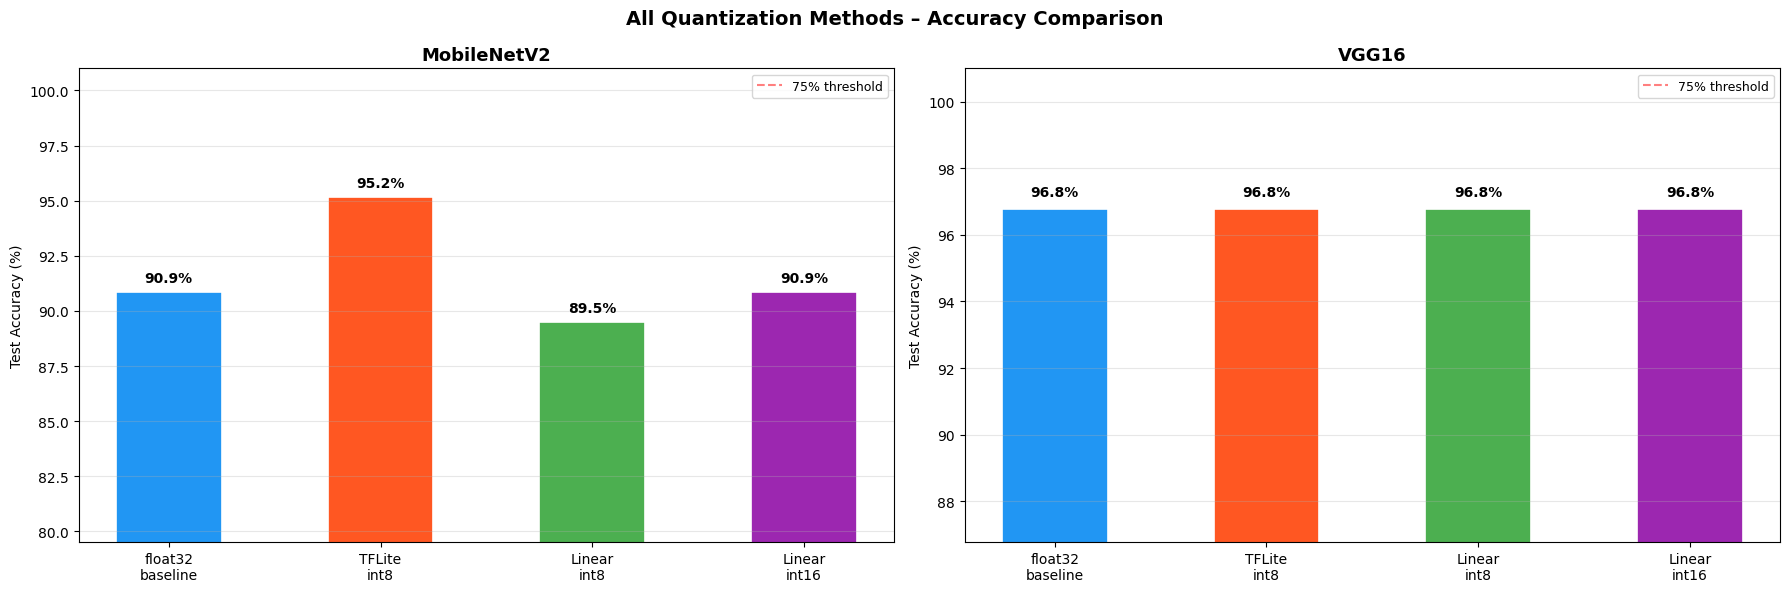


✅ All tasks complete. Notebook outputs saved.


In [22]:
# ─── Final Combined Comparison Bar Chart ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('All Quantization Methods – Accuracy Comparison', fontsize=14, fontweight='bold')

methods = ['float32\nbaseline', 'TFLite\nint8', 'Linear\nint8', 'Linear\nint16']
colors  = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

for ax, (model_name, base_acc, tfl_acc, lq8_acc, lq16_acc) in zip(
    axes,
    [
        ('MobileNetV2', mobilenet_test_acc, mob_acc_q,
         lq_results[8]['MobileNetV2']['acc'], lq_results[16]['MobileNetV2']['acc']),
        ('VGG16', vgg16_test_acc, vgg_acc_q,
         lq_results[8]['VGG16']['acc'], lq_results[16]['VGG16']['acc'])
    ]
):
    accs = [base_acc*100, tfl_acc*100, lq8_acc*100, lq16_acc*100]
    bars = ax.bar(methods, accs, color=colors, edgecolor='white', linewidth=1.2, width=0.5)
    ax.set_ylim(max(0, min(accs)-10), 101)
    ax.set_title(f'{model_name}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Test Accuracy (%)')
    ax.grid(axis='y', alpha=0.3)
    ax.axhline(y=75, color='red', linestyle='--', alpha=0.5, label='75% threshold')
    ax.legend(fontsize=9)
    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('final_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n✅ All tasks complete. Notebook outputs saved.")